# SMR multilink modelization


The following code is based in 2 PyPSA CHP multilink axamples: [basic example](https://pypsa.readthedocs.io/en/latest/examples/chp-fixed-heat-power-ratio.html) and [Biomass example](https://pypsa.readthedocs.io/en/latest/examples/biomass-synthetic-fuels-carbon-management.html). 

**The code runs correctly without "infeasible error" with a multiple output from the SMR.** But, it's seems to be tricky with managing costs 

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

import pypsa

In [37]:
network = pypsa.Network() # Creates empty PyPSA network object called network
network.set_snapshots(range(10)) #set time frame of simulation
# marginal costs in EUR/MWh
marginal_costs = {"uranium": 10, "Spain_gas": 30, "Spain_grid": 50}

network.add("Carrier", "Gas_CHP",) # define carriers (optional)
network.add("Carrier", "SMR_CHP",)
network.add("Carrier", "heat",)
network.add("Carrier","electricity",)

network.add("Bus", "Industry Electricity", carrier="electricity") # 1) Main Buses & loads
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=6)
network.add("Bus", "Industry Heat", carrier="heat")
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=4)

network.add("Bus", "uranium", carrier="SMR_CHP")                  # 2)  Fuel buses
network.add("Bus", "Spain gas", carrier="Gas_CHP")
network.add("Bus", "Spain_grid", carrier="electricity")
#---------------------------------------------------------------------------------------
network.add("Store", "Spain gas", bus="Spain gas",
    e_initial=100, 
    e_nom=50,    # set pre-existing e_nom=50?
    e_nom_extendable=True, # 
    # capital_cost=1,
    marginal_cost=pd.Series([10,10,15,30,35,28,20,19,10,10], index=network.snapshots) 
)
network.add( "Link", "Gas_CHP",               
    bus0="Spain gas",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    carrier="Gas_CHP",
    p_nom=10,            # fixed p_nom Gas installed
    capital_cost=1,     # fixed period costs of extending p_nom by 1 MW
    efficiency=0.6, 
    efficiency2=0.4,
)
#---------------------------------------------------------------------------------------
network.add("Store", "uranium", bus="uranium",
    e_initial=100, 
    e_nom=0, # set pre-existing e_nom=0?
    e_nom_extendable=True,
    # capital_cost=1,  
    marginal_cost=marginal_costs["uranium"]
) 
network.add( "Link", "SMR_CHP",
    bus0="uranium",
    bus1="Industry Electricity",
    bus2="Industry Heat", 
    carrier="SMR_CHP",
    # p_nom=10,
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=1, #annualized USD
    efficiency=0.6, 
    efficiency2=0.4,
)
#---------------------------------------------------------------------------------------
network.add("Store", "electric energy", bus="Spain_grid",
    e_initial=1e7, 
    e_nom=100, # set pre-existing e_nom=0?
    e_nom_extendable=True,
    # capital_cost=1,  
    marginal_cost=marginal_costs["Spain_grid"]
)
network.add("Link", "Link_Spain_Grid",
    bus0="Spain_grid",
    bus1="Industry Electricity",
    carrier="electricity",
    p_nom_extendable=True,
    capital_cost=1,    #  $/MW per period
    marginal_cost=0,  # $/MWh no aditional cost
    efficiency=0.95)      #  electricity transport

Index(['Link_Spain_Grid'], dtype='object')

In [34]:
network.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 95 primals, 205 duals
Objective: 1.01e+03
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

total_cost= 1010.0 [USD]
capital cost= 0.0 [USD]
summed marginal cost= 1010.0 [USD]


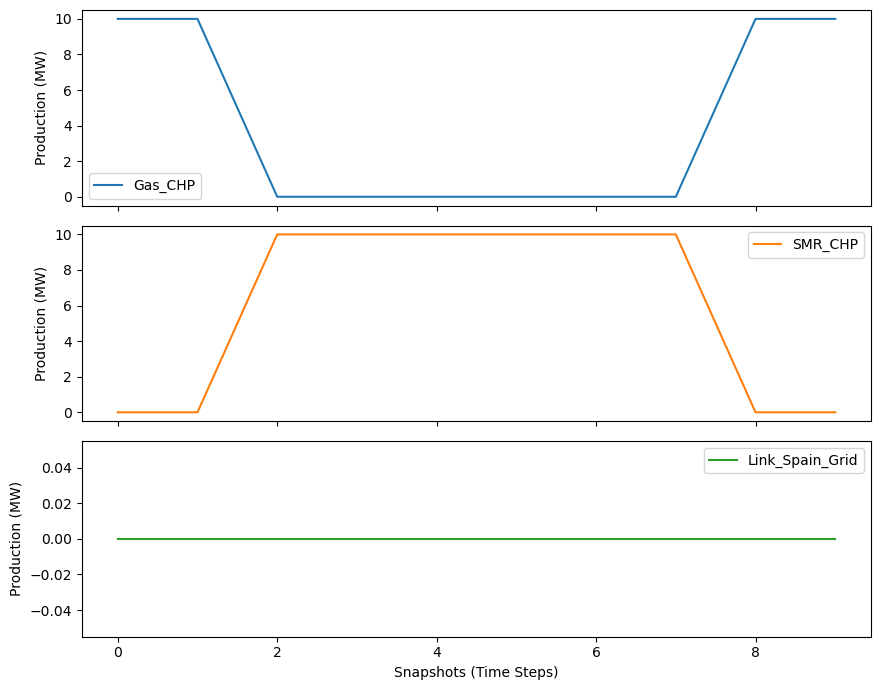

In [35]:
# Plot production view with subplots
ax = network.links_t.p0.plot(subplots=True, figsize=(9, 7))
# Add labels for x and y axes on each subplot
for subplot in ax:
    subplot.set_xlabel("Snapshots (Time Steps)")  # Label for x-axis
    subplot.set_ylabel("Production (MW)")         # Label for y-axis
# Adjust layout to prevent overlapping
plt.tight_layout()
# print(network.links.p_nom_opt)
total_cost = network.objective + network.objective_constant;  # USD
print("total_cost=", total_cost,"[USD]")
print("capital cost=", network.objective_constant, "[USD]")
print("summed marginal cost=", network.objective, "[USD]")

In [36]:
print("SMR Electricity Output:", network.links_t.p1["SMR_CHP"].sum())  # -MW
print("SMR Heat Output:", network.links_t.p2["SMR_CHP"].sum())         # -MW
print("SMR Uranium Fuel Consumption:", network.links_t.p0["SMR_CHP"].sum())    #+ MW
print("Gas_CHP Electricity Output:", network.links_t.p1["Gas_CHP"].sum())
print("Gas_CHP Gas Consumption:", network.links_t.p0["Gas_CHP"].sum())

SMR Electricity Output: -36.0
SMR Heat Output: -24.0
SMR Uranium Fuel Consumption: 60.0
Gas_CHP Electricity Output: -24.0
Gas_CHP Gas Consumption: 40.0


Note that negative values for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive). 

- network.links_t.p0 # energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE
- network.links_t.p1 # energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)
- network.links_t.p2 # energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)

<!-- Note that `negative values` for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive).

Here there is a brief explanation for each of the following code lines: 
- network.links_t.p0: `energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE`
- network.links_t.p1: `energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)`
- network.links_t.p2: `energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)` -->

<!-- 
Starts SMR model versión2 with network `n2`

## Note: 
About de network initialization (can be useful for some future research)

**Network Initialization**: `n1 = pypsa.Network(url)`
   - Creates a PyPSA `Network` object `n1`
   - Automatically downloads and loads the pre-configured energy system model containing:
     - Buses (energy nodes)
     - Generators (power plants)
     - Loads (energy demands)
     - Transmission lines
     - Time-dependent constraints

Key Features of This Approach:
- **Reproducibility**: Loads a standardized benchmark model
- **Time-Saving**: Avoids manual network construction (~1000+ lines of setup code)
- **Research-Ready**: Contains realistic European power system data (likely from [PyPSA-Eur](https://pypsa-eur.readthedocs.io/)) -->